In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch


[-1.31881679 -2.62572417]
(1000, 2)


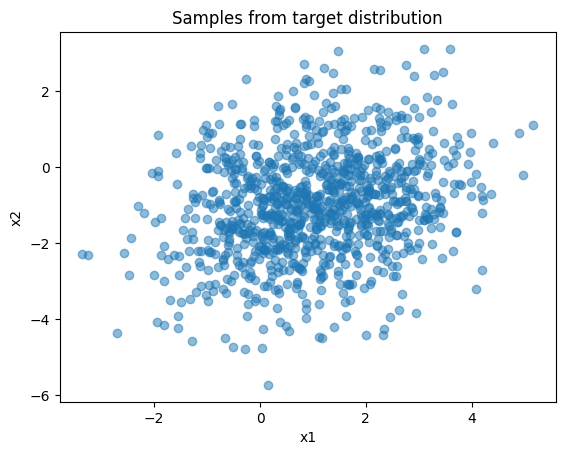

In [2]:
# target distribution

np.random.seed(0)

def p_x():
    return np.random.multivariate_normal(mean=[1,-1], cov=[[2,0.5],[0.5,2]])

print(p_x())

generate_samples = 1000
samples_target = np.array([p_x() for _ in range(generate_samples)])
print(samples_target.shape)
plt.scatter(samples_target[:,0], samples_target[:,1], alpha=0.5)
plt.title("Samples from target distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [3]:
# Base distribution
def p_u():
    return np.random.multivariate_normal(mean=[0,0], cov=[[1,0],[0,1]])
print(p_u())

[ 0.04613506 -0.95837448]


In [4]:
# i want to make the transformation from u to x as an affine transformation
# x = A*u + b
# where A is a 2x2 matrix and b is a 2x1 vector
# we can learn A and b using maximum likelihood estimation
class AffineFlow(nn.Module):
    def __init__(self, input_dim):
        super(AffineFlow, self).__init__()
        self.A = nn.Parameter(torch.eye(input_dim))   # 2x2 matrix
        self.b = nn.Parameter(torch.zeros(input_dim)) # 2D shift

    # forward: latent u -> x
    def forward(self, u):
        return u @ self.A.T + self.b

    # inverse: x -> latent u
    def inverse(self, x):
        A_inv = torch.inverse(self.A)
        return (x - self.b) @ A_inv.T

    # log-det Jacobian of inverse
    def log_det_jacobian(self):
        return torch.log(torch.abs(torch.det(self.A)) + 1e-8)  

In [5]:
def log_prob_base(u):
    # Standard Gaussian log-probability
    return -0.5 * torch.sum(u**2, dim=1) - 0.5 * 2 * np.log(2*np.pi)


In [6]:
# -----------------------------
# Training setup
# -----------------------------
model = AffineFlow(input_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
num_iterations = 2000
batch_size = 64

In [7]:
# -----------------------------
# Training loop
# -----------------------------
for i in range(num_iterations):
    x_batch = samples_target[np.random.choice(samples_target.shape[0], batch_size)]  # target samples
    x_batch = torch.tensor(x_batch, dtype=torch.float32)
    u_batch = model.inverse(x_batch)     # map to latent space

    log_p_u = log_prob_base(u_batch)
    log_det_jacobian = model.log_det_jacobian()

    # Negative log-likelihood
    loss = (-log_p_u + log_det_jacobian).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 200 == 0:
        print(f"Iteration {i}, NLL: {loss.item():.4f}")


Iteration 0, NLL: 5.4109
Iteration 200, NLL: 3.5466
Iteration 400, NLL: 3.4343
Iteration 600, NLL: 3.4180
Iteration 800, NLL: 3.3952
Iteration 1000, NLL: 3.5240
Iteration 1200, NLL: 3.3326
Iteration 1400, NLL: 3.6780
Iteration 1600, NLL: 3.3173
Iteration 1800, NLL: 3.4640


[ 1.1328835  -0.92918473] [[1.91598503 0.5078125 ]
 [0.5078125  1.99246655]]


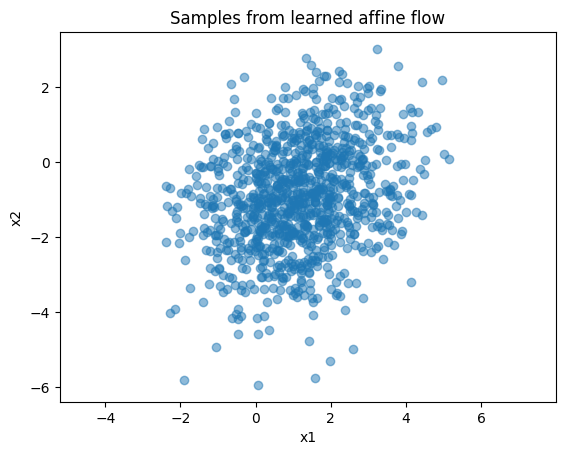

In [8]:
# -----------------------------
# Verification: generate samples
# -----------------------------
with torch.no_grad():
    u_samples = torch.randn(1000, 2)
    x_samples = model.forward(u_samples)

x_samples = x_samples.numpy()
print(x_samples.mean(axis=0), np.cov(x_samples, rowvar=False))
plt.scatter(x_samples[:,0], x_samples[:,1], alpha=0.5)
plt.title("Samples from learned affine flow")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.show()